In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
RandomForestSet=pd.read_csv("csvSet.csv")
display(RandomForestSet.head())


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
print(RandomForestSet['RiskLevel'].unique())

['high risk' 'low risk' 'mid risk']


In [5]:
RandomForestSet['RiskLevel']=RandomForestSet['RiskLevel'].map({'low risk':0,'mid risk':1,'high risk':2})
RandomForestSet.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [6]:
RandomForestSet.to_csv('RandomForestSet.csv', index=False)
print("hurray we cleaned our data")

hurray we cleaned our data


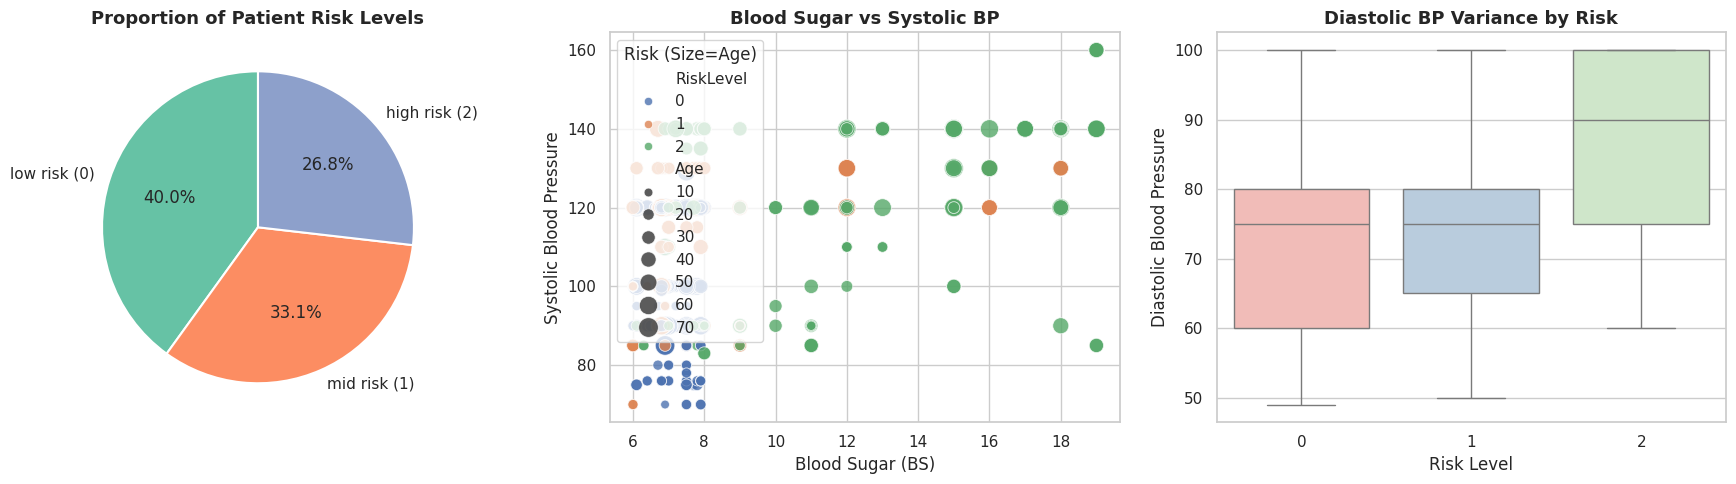

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

risk_counts = RandomForestSet["RiskLevel"].value_counts().sort_index()
labels = ['low risk (0)', 'mid risk (1)', 'high risk (2)']
colors = sns.color_palette("Set2")[:3]

axes[0].pie(
    risk_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[0].set_title("Proportion of Patient Risk Levels", fontsize=13, weight="bold")

sns.scatterplot(
    ax=axes[1],
    data=RandomForestSet,
    x="BS",
    y="SystolicBP",
    hue="RiskLevel",
    palette="deep",
    size="Age",
    sizes=(40, 200),
    alpha=0.8,
)
axes[1].set_title("Blood Sugar vs Systolic BP", fontsize=13, weight="bold")
axes[1].set_xlabel("Blood Sugar (BS)")
axes[1].set_ylabel("Systolic Blood Pressure")
axes[1].legend(title="Risk (Size=Age)", loc="upper left")

sns.boxplot(
    ax=axes[2],
    data=RandomForestSet,
    x="RiskLevel",
    y="DiastolicBP",
    hue="RiskLevel",
    palette="Pastel1",
    legend=False,
)
axes[2].set_title("Diastolic BP Variance by Risk", fontsize=13, weight="bold")
axes[2].set_xlabel("Risk Level")
axes[2].set_ylabel("Diastolic Blood Pressure")

plt.tight_layout()
plt.show() 

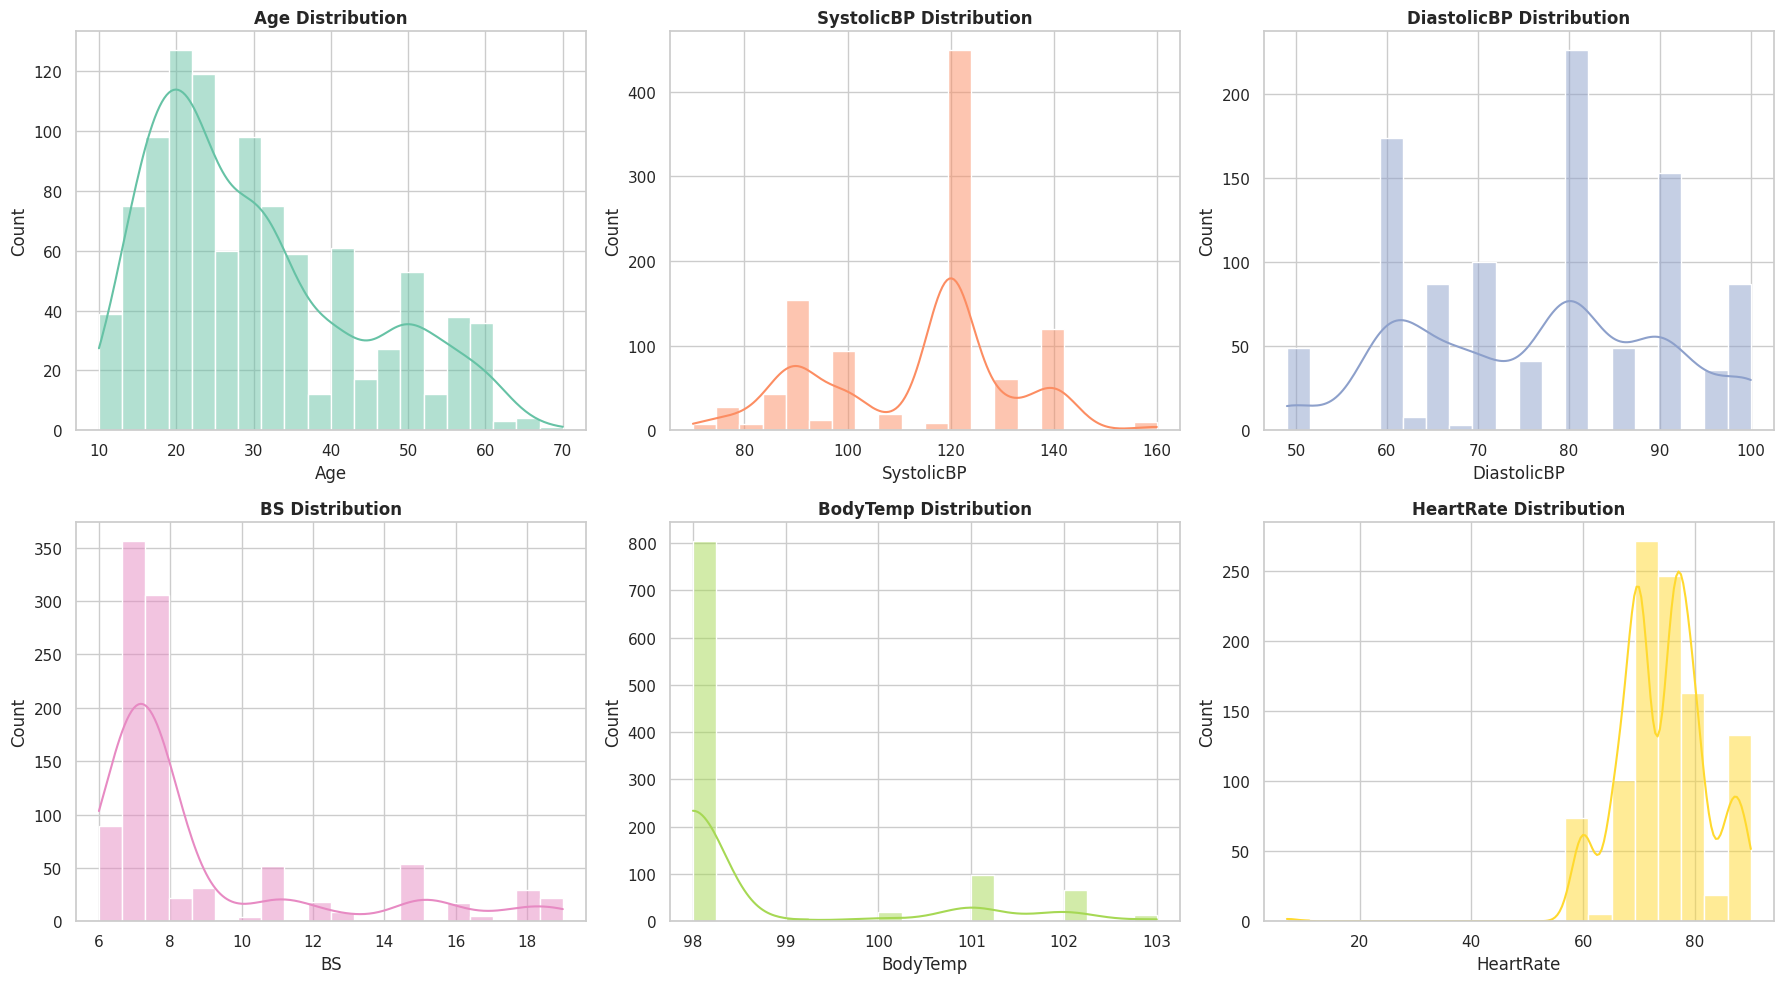

In [8]:
numeric_cols = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=RandomForestSet,
        x=col,
        bins=20,
        kde=True,
        ax=axes[i],
        color=sns.color_palette("Set2")[i % 8],
    )
    axes[i].set_title(f"{col} Distribution", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()